#Libs and functions

In [3]:
# Cell 1: Load the library
# If developing locally, comment out wget and upload espresso_charts.py manually
!wget -q https://raw.githubusercontent.com/sh-engineering/espresso_charts/main/espresso_charts.py -O espresso_charts.py
import importlib, espresso_charts
importlib.reload(espresso_charts)
from espresso_charts import *
import requests, base64

# Authenticate for Vertex AI (required for Gemini Veo video generation)
from google.colab import auth
auth.authenticate_user()

from google.colab import userdata
ELEVENLABS_API_KEY = userdata.get('ELEVENLABS_API_KEY')
GEMINI_API_KEY = userdata.get('GEMINI_API_KEY')

# Cell 1: Credentials & tools (your Colab setup)
uploader = GitHubUploader(token=userdata.get("GITHUB_TOKEN"), owner="sh-engineering", repo="espresso_charts_stories")
substack = SubstackPublisher("https://espressocharts.substack.com", "espressochartsai@gmail.com", userdata.get("SUBSTACK_PASSWORD"))

# Cell 2: Load the runner (one-time or wget from GitHub)
!wget -q https://raw.githubusercontent.com/sh-engineering/espresso_charts/main/espresso_runner.py -O espresso_runner.py



In [4]:
%run /content/espresso_charts.py

In [5]:
# Check repo

token = userdata.get("GITHUB_TOKEN")
owner = "sh-engineering"
repo = "espresso_charts_stories"

# Test 1: Can you see the repo?
r = requests.get(
    f"https://api.github.com/repos/{owner}/{repo}",
    headers={"Authorization": f"token {token}"}
)
print("Repo:", r.status_code, r.json().get("default_branch"))

Repo: 200 main


In [6]:
def save_chart(fig, path, dpi=200):
    """Save chart with locked dimensions. Never uses bbox_inches='tight'."""
    fig.savefig(path, dpi=dpi, bbox_inches=None, pad_inches=0, facecolor=fig.get_facecolor())


In [7]:
# -*- coding: utf-8 -*-
"""
espresso_runner.py — JSON-driven asset generator for Espresso Charts.

Usage (in Colab):
    1. Paste this file into a cell (or !wget it from GitHub)
    2. Load your config:  config = json.load(open("story_config.json"))
    3. Run:               run_config(config)

Everything — PNGs, MP4s, voiceovers, reels, GitHub pushes — is driven
by the JSON. Claude outputs JSON, you paste it, hit run.
"""

import json
import pandas as pd
import matplotlib.pyplot as plt


# ============================================================================
# SAVE HELPER (locked dimensions — never uses bbox_inches='tight')
# ============================================================================

def save_chart(fig, path, dpi=200):
    """Save chart with locked dimensions. Never uses bbox_inches='tight'."""
    fig.savefig(path, dpi=dpi, bbox_inches=None, pad_inches=0, facecolor=fig.get_facecolor())


# ============================================================================
# COLOR PALETTE — referenced by name in JSON
# ============================================================================
COLOR_MAP = {
    "color_blue":   "#3F5B83",
    "color_orange": "#DD6B20",
    "color_green":  "#4D5523",
    "color_sand":   "#CDAF7B",
}

# ============================================================================
# CHART TYPE → FUNCTION DISPATCH
# ============================================================================
# Static (PNG)
CHART_FUNCTIONS = {
    "bar":    "eSingleBarChartNewInstagram",
    "donut":  "eDonutChartInstagram",
    "line":   "eMultiLineChartInstagram",
    "stem":   "eStemChartNewInstagram",
}

# Animated (MP4)
ANIMATE_FUNCTIONS = {
    "cover_animate":  "eCoverTileAnimateInstagram",
    "bar_animate":    "eSingleBarChartAnimateInstagram",
    "stem_animate":   "eStemChartAnimateInstagram",
    "line_animate":   "eMultiLineChartAnimateInstagram",
    "donut_animate":  "eDonutChartAnimateInstagram",
    "opening_frame": "eGenerateOpeningFrame",
}


# ============================================================================
# HELPERS
# ============================================================================

def resolve_colors(params):
    """Replace color name strings ('color_blue') with hex values in params."""
    resolved = {}
    for k, v in params.items():
        if isinstance(v, str) and v in COLOR_MAP:
            resolved[k] = COLOR_MAP[v]
        elif isinstance(v, list):
            resolved[k] = [COLOR_MAP[x] if isinstance(x, str) and x in COLOR_MAP else x for x in v]
        elif isinstance(v, tuple):
            resolved[k] = tuple(COLOR_MAP[x] if isinstance(x, str) and x in COLOR_MAP else x for x in v)
        else:
            resolved[k] = v
    return resolved


def apply_defaults(params, defaults):
    """Merge defaults into params (params win on conflicts)."""
    merged = {}
    for k, v in defaults.items():
        if k not in params:
            merged[k] = v
    merged.update(params)
    return merged


def build_cover_params(cover_cfg, defaults):
    """Build full kwargs for eCoverTileInstagram from cover config + defaults."""
    params = dict(cover_cfg)  # copy
    params.setdefault("suptitle_font", defaults.get("suptitle_font", "DejaVu Serif"))
    params.setdefault("subtitle_font", defaults.get("subtitle_font", "DejaVu Sans"))
    params.setdefault("face_color", defaults.get("face_color", "#F5F0E6"))
    params.setdefault("px_width", defaults.get("px_width", 1080))
    params.setdefault("px_height", defaults.get("px_height", 1350))
    params.setdefault("dpi", defaults.get("dpi", 200))
    return resolve_colors(params)


def build_chart_params(chart_cfg, defaults):
    """Build full kwargs for a chart function from chart config + defaults."""
    params = dict(chart_cfg.get("params", {}))
    chart_type = chart_cfg["type"]

    # Apply shared defaults for static charts
    if chart_type in ("bar", "stem"):
        params.setdefault("face_color", defaults.get("face_color"))
        params.setdefault("instagram", True)
        params.setdefault("px_width", defaults.get("px_width", 1080))
        params.setdefault("px_height", defaults.get("px_height", 1350))
        params.setdefault("dpi", defaults.get("dpi", 200))
        params.setdefault("aspect_ratio", None)
        params.setdefault("suptitle_font", defaults.get("suptitle_font"))
        params.setdefault("subtitle_font", defaults.get("subtitle_font"))
    elif chart_type == "donut":
        params.setdefault("face_color", defaults.get("face_color"))
        params.setdefault("instagram", True)
        params.setdefault("dpi", defaults.get("dpi", 200))
        params.setdefault("suptitle_font", defaults.get("suptitle_font"))
        params.setdefault("subtitle_font", defaults.get("subtitle_font"))
    elif chart_type == "line":
        params.setdefault("face_color", defaults.get("face_color"))
        params.setdefault("dpi", defaults.get("dpi", 200))
        params.setdefault("suptitle_font", defaults.get("suptitle_font"))
        params.setdefault("subtitle_font", defaults.get("subtitle_font"))

    # Convert y_limits list → tuple (JSON doesn't have tuples)
    if "y_limits" in params and isinstance(params["y_limits"], list):
        params["y_limits"] = tuple(params["y_limits"])

    return resolve_colors(params)


def build_animate_params(anim_cfg, defaults):
    """Build kwargs for an animated chart function."""
    params = dict(anim_cfg.get("params", {}))
    anim_type = anim_cfg["type"]

    if anim_type == "cover_animate":
        params.setdefault("suptitle_font", defaults.get("suptitle_font"))
        params.setdefault("subtitle_font", defaults.get("subtitle_font"))
        params.setdefault("face_color", defaults.get("face_color"))
    else:
        params.setdefault("face_color", defaults.get("face_color"))
        params.setdefault("suptitle_font", defaults.get("suptitle_font"))
        params.setdefault("subtitle_font", defaults.get("subtitle_font", "DejaVu Sans"))

    if "y_limits" in params and isinstance(params["y_limits"], list):
        params["y_limits"] = tuple(params["y_limits"])

    return resolve_colors(params)


def make_df(data_dict):
    """Convert a JSON data dict to a pandas DataFrame."""
    return pd.DataFrame(data_dict)


def file_path(story_id, chart_idx, ext):
    """Generate consistent output filenames."""
    return f"story{story_id}_chart{chart_idx}.{ext}"


# ============================================================================
# MAIN RUNNER
# ============================================================================

def run_config(config, story_ids=None, only=None, chart_indices=None,
               skip_reels=False, skip_github=False):
    """
    Execute the asset pipeline from a JSON config dict.

    Parameters
    ----------
    config : dict
        Parsed JSON config (see story_config.json for schema).
    story_ids : int, list[int], or None
        Run only these story IDs.  None = all stories.
        Example: story_ids=2  or  story_ids=[1, 3]
    only : str, list[str], or None
        Run only these phases: 'cover', 'charts', 'copy', 'publish', 'reel'.
        None = all phases.
        Example: only='charts'  or  only=['cover', 'charts']
    chart_indices : int, list[int], or None
        When only='charts', generate only these chart indices (1-based).
        None = all charts in the story.
        Example: chart_indices=2  (just the second chart)
    skip_reels : bool
        If True, skip animated charts / voiceover / music / audio mix.
        (Equivalent to excluding 'reel' from `only`.)
    skip_github : bool
        If True, skip GitHub uploads.

    Examples
    --------
    run_config(config)                                  # everything
    run_config(config, story_ids=2)                     # just story 2
    run_config(config, story_ids=1, only='charts')      # story 1 PNGs only
    run_config(config, story_ids=1, only='charts',
               chart_indices=2)                         # story 1, chart 2 only
    run_config(config, story_ids=[0, 2], only='reel')   # reels for stories 0 & 2
    run_config(config, story_ids=3, only='cover')       # just regenerate a cover
    """
    defaults = config.get("defaults", {})
    week = config["week"]
    dpi = defaults.get("dpi", 200)

    story_year = week["year"]
    story_month = week["month"]
    story_week_start = week["week_start"]
    base_path = f"assets/{story_year}/{story_month}/{story_week_start}"

    # Normalize filter params
    if isinstance(story_ids, int):
        story_ids = [story_ids]
    if isinstance(only, str):
        only = [only]
    if isinstance(chart_indices, int):
        chart_indices = [chart_indices]

    # Build phase set
    phases = set(only) if only else {'cover', 'charts', 'copy', 'publish', 'reel'}
    if skip_reels:
        phases.discard('reel')

    all_outputs = []  # track generated files for GitHub push

    for story in config["stories"]:
        sid = story["id"]
        if story_ids is not None and sid not in story_ids:
            continue

        slug = story.get("slug", f"story{sid}")
        print(f"\n{'='*60}")
        print(f"  STORY {sid}: {slug}")
        print(f"{'='*60}")

        # ── COVER (PNG) ─────────────────────────────────────────────
        if "cover" in story and 'cover' in phases:
            cover_params = build_cover_params(story["cover"], defaults)
            out_file = file_path(sid, 0, "png")
            print(f"  [cover] → {out_file}")
            fig, ax = eCoverTileInstagram(**cover_params)
            save_chart(fig, out_file, dpi=dpi)
            all_outputs.append(out_file)

        # ── STATIC CHARTS (PNG) ─────────────────────────────────────
        if 'charts' in phases:
            for ci, chart in enumerate(story.get("charts", []), start=1):
                if chart_indices is not None and ci not in chart_indices:
                    continue
                chart_type = chart["type"]
                fn_name = CHART_FUNCTIONS.get(chart_type)
                if not fn_name:
                    print(f"  [chart {ci}] ⚠ Unknown type '{chart_type}', skipping")
                    continue

                fn = globals().get(fn_name)
                if fn is None:
                    print(f"  [chart {ci}] ⚠ Function '{fn_name}' not found, skipping")
                    continue

                df = make_df(chart["data"])
                params = build_chart_params(chart, defaults)
                out_file = file_path(sid, ci, "png")
                print(f"  [chart {ci}] {fn_name} → {out_file}")
                # In run_config(), right before: fig, ax = fn(df_chart=df, **params)
                # Add this:
                for _dk in ('label_custom_offset', 'value_label_offset_x', 'value_label_offset_y'):
                    if _dk in params:
                        print(f"  DEBUG {_dk}: {type(params[_dk]).__name__} = {params[_dk]}")

                fig, ax = fn(df_chart=df, **params)
                save_chart(fig, out_file, dpi=dpi)
                all_outputs.append(out_file)

        # ── COPY (text assets) ──────────────────────────────────────
        if 'copy' in phases and 'copy' in story:
            copy = story["copy"]

            # Instagram caption + hashtags → one file, ready to paste
            if "instagram" in copy:
                ig = copy["instagram"]
                ig_file = f"story{sid}_instagram.txt"
                parts = []
                if ig.get("caption"):
                    parts.append(ig["caption"].strip())
                if ig.get("hashtags"):
                    parts.append("")  # blank line separator
                    parts.append(ig["hashtags"].strip())
                with open(ig_file, "w") as f:
                    f.write("\n".join(parts))
                print(f"  [copy] instagram → {ig_file}")
                all_outputs.append(ig_file)

            # Instagram reel caption (if different from post)
            if "instagram_reel" in copy:
                igr = copy["instagram_reel"]
                igr_file = f"story{sid}_instagram_reel.txt"
                parts = []
                if igr.get("caption"):
                    parts.append(igr["caption"].strip())
                if igr.get("hashtags"):
                    parts.append("")
                    parts.append(igr["hashtags"].strip())
                with open(igr_file, "w") as f:
                    f.write("\n".join(parts))
                print(f"  [copy] instagram_reel → {igr_file}")
                all_outputs.append(igr_file)

            # Substack article → markdown file
            if "substack_article" in copy:
                sa = copy["substack_article"]
                sa_file = f"story{sid}_substack_article.md"
                lines = []
                if sa.get("headline"):
                    lines.append(f"# {sa['headline']}")
                if sa.get("subhead"):
                    lines.append(f"*{sa['subhead']}*")
                if sa.get("headline") or sa.get("subhead"):
                    lines.append("")
                if sa.get("body"):
                    lines.append(sa["body"].strip())
                if sa.get("tags"):
                    lines.append("")
                    lines.append(f"**Tags:** {sa['tags'].strip()}")
                with open(sa_file, "w") as f:
                    f.write("\n".join(lines))
                print(f"  [copy] substack_article → {sa_file}")
                all_outputs.append(sa_file)

            # Substack note → short text file
            if "substack_note" in copy:
                sn = copy["substack_note"]
                sn_file = f"story{sid}_substack_note.txt"
                with open(sn_file, "w") as f:
                    f.write(sn.strip())
                print(f"  [copy] substack_note → {sn_file}")
                all_outputs.append(sn_file)

            # Substack Chart Notes → individual markdown files
            if "substack_chart_notes" in copy:
                for ni, note in enumerate(copy["substack_chart_notes"]):
                    note_file = f"story{sid}_chart_note_{note.get('day', ni)}.md"
                    note_lines = []
                    if note.get('image_asset'):
                        note_lines.append(f"**Image:** {note['image_asset']}")
                        note_lines.append("")
                    note_lines.append(note.get('text', '').strip())
                    with open(note_file, "w") as f:
                        f.write("\n".join(note_lines))
                    print(f"  [copy] chart_note → {note_file}")
                    all_outputs.append(note_file)

        # ── PUBLISH (Substack) ──────────────────────────────────────
        if 'publish' in phases and 'copy' in story:
            copy = story["copy"]
            sa = copy.get("substack_article")
            if sa and sa.get("body"):
                publish_at = sa.get("publish_at")  # UTC string or None

                try:
                    if publish_at:
                        print(f"  [publish] substack scheduled → {publish_at}")
                        substack.post_scheduled(
                            title=sa.get("headline", ""),
                            subtitle=sa.get("subhead", ""),
                            body=sa["body"],
                            publish_at=publish_at,
                        )
                    else:
                        print(f"  [publish] substack draft")
                        substack.post_draft(
                            title=sa.get("headline", ""),
                            subtitle=sa.get("subhead", ""),
                            body=sa["body"],
                        )
                    print(f"  ✓ substack done")
                except Exception as e:
                    print(f"  ✗ substack publish failed — {e}")

        # ── REELS (MP4) ─────────────────────────────────────────────
        if 'reel' not in phases or skip_reels or "reel" not in story:
            continue

        reel = story["reel"]
        scene_files = []

        # Animated chart scenes
        for ai, anim in enumerate(reel.get("animated_charts", [])):
            anim_type = anim["type"]
            fn_name = ANIMATE_FUNCTIONS.get(anim_type)
            if not fn_name:
                print(f"  [reel scene {ai}] ⚠ Unknown type '{anim_type}', skipping")
                continue

            fn = globals().get(fn_name)
            if fn is None:
                print(f"  [reel scene {ai}] ⚠ Function '{fn_name}' not found, skipping")
                continue

            params = build_animate_params(anim, defaults)
            out_file = f"story{sid}_chart{ai}_animated.mp4"
            params["output_file"] = out_file
            print(f"  [reel scene {ai}] {fn_name} → {out_file}")

            if anim_type == "cover_animate":
                fn(**params)
            elif anim_type == "opening_frame":
                # Opening frame uses Gemini Veo — different call signature
                of_params = dict(anim.get("params", {}))
                of_params["output_file"] = out_file
                of_params.setdefault("gemini_api_key", GEMINI_API_KEY)
                of_params = resolve_colors(of_params)
                eGenerateOpeningFrame(**of_params)
            else:
                df = make_df(anim["data"])
                fn(df, **params)

            scene_files.append(out_file)

        # Concatenate scenes → reel
        reel_file = f"story{sid}_reel.mp4"
        if len(scene_files) > 1:
            print(f"  [concat] {scene_files} → {reel_file}")
            eConcatenateMP4(scene_files, reel_file)
        elif len(scene_files) == 1:
            import shutil
            shutil.copy(scene_files[0], reel_file)
        else:
            print(f"  [reel] ⚠ No animated scenes, skipping reel")
            continue

        # Voiceover
        vo_cfg = reel.get("voiceover", {})
        if vo_cfg.get("text"):
            vo_defaults = defaults.get("voiceover", {})
            vo_file = f"story{sid}_voice.mp3"
            print(f"  [voiceover] → {vo_file}")
            eGenerateVoiceover(
                text=vo_cfg["text"],
                api_key=ELEVENLABS_API_KEY,
                voice_name=vo_cfg.get("voice_name", vo_defaults.get("voice_name", "josh")),
                model=vo_cfg.get("model", vo_defaults.get("model", "multilingual_v2")),
                stability=vo_cfg.get("stability", vo_defaults.get("stability", 0.50)),
                speed=vo_cfg.get("speed", vo_defaults.get("speed", 0.95)),
                output_file=vo_file,
            )
        else:
            vo_file = None

        # Background music
        music_cfg = reel.get("music", {})
        music_file = None
        if music_cfg.get("preset") or music_cfg.get("prompt"):
            music_file = f"bg_music{sid}.mp3"
            print(f"  [music] preset={music_cfg.get('preset', 'custom')} → {music_file}")
            eGenerateMusic(
                preset=music_cfg.get("preset"),
                prompt=music_cfg.get("prompt"),
                api_key=ELEVENLABS_API_KEY,
                duration_ms=music_cfg.get("duration_ms", 20000),
                output_file=music_file,
            )

        # Audio mix
        if vo_file or music_file:
            mix_defaults = defaults.get("audio_mix", {})
            final_file = f"story{sid}_reel_with_audio.mp4"
            print(f"  [audio mix] → {final_file}")
            mix_kwargs = {
                "vo_delay": mix_defaults.get("vo_delay", 0.5),
                "vo_volume": mix_defaults.get("vo_volume", 1.0),
                "music_volume": mix_defaults.get("music_volume", 0.12),
                "music_fade_in": mix_defaults.get("music_fade_in", 0.5),
                "music_fade_out": mix_defaults.get("music_fade_out", 2.0),
            }
            # Override with per-story values if present
            audio_overrides = reel.get("audio_mix", {})
            mix_kwargs.update(audio_overrides)

            eAddAudio(
                reel_file,
                voiceover_file=vo_file,
                music_file=music_file,
                output_file=final_file,
                **mix_kwargs,
            )
            all_outputs.append(final_file)
        else:
            all_outputs.append(reel_file)

    # ── GITHUB PUSH ──────────────────────────────────────────────────
    if not skip_github:
        # Save config JSON to disk for archiving
        config_file = "story_config.json"
        with open(config_file, "w") as f:
            json.dump(config, f, indent=2, ensure_ascii=False)
        all_outputs.append(config_file)

        print(f"\n{'='*60}")
        print(f"  GITHUB PUSH → {base_path}/")
        print(f"{'='*60}")
        push_ok, push_fail = 0, 0
        for f in all_outputs:
            dest = f"{base_path}/{f}"
            try:
                uploader.push_file(local_path=f"/content/{f}", dest=dest)
                print(f"  ✓ {f} → {dest}")
                push_ok += 1
            except Exception as e:
                print(f"  ✗ {f} — {e}")
                push_fail += 1
        if push_fail:
            print(f"\n  ⚠ {push_ok} pushed, {push_fail} failed")

    print(f"\n✓ Done. {len(all_outputs)} files generated.")
    return all_outputs


# ============================================================================
# CONVENIENCE: Load & run from file
# ============================================================================

def run_from_json(json_path, **kwargs):
    """Load a JSON config file and run it."""
    with open(json_path, "r") as f:
        config = json.load(f)
    return run_config(config, **kwargs)


# ============================================================================
# SELECTIVE GITHUB PUSH
# ============================================================================

def push_assets(config, files=None, story_ids=None, types=None):
    """
    Push specific assets to GitHub without regenerating.

    Parameters
    ----------
    config : dict
        Parsed JSON config (for week path info).
    files : str, list[str], or None
        Explicit filenames to push.
        Example: files="story1_chart2.png"
        Example: files=["story1_chart0.png", "story2_reel_with_audio.mp4"]
    story_ids : int, list[int], or None
        Push all assets matching these story IDs.
        Example: story_ids=2  →  pushes story2_*.png + story2_*.mp4
    types : str, list[str], or None
        Filter by file extension: 'png', 'mp4', 'mp3', 'txt', 'md'.
        Example: types='png'  →  only push PNGs

    Examples
    --------
    push_assets(config, files="story1_chart2.png")
    push_assets(config, story_ids=2)
    push_assets(config, story_ids=[1, 3], types='mp4')
    push_assets(config, story_ids=0, types='png')
    """
    import glob
    import os

    week = config["week"]
    base_path = f"assets/{week['year']}/{week['month']}/{week['week_start']}"

    # Normalize params
    if isinstance(files, str):
        files = [files]
    if isinstance(story_ids, int):
        story_ids = [story_ids]
    if isinstance(types, str):
        types = [types]

    # Build file list
    if files:
        to_push = files
    else:
        # Discover all generated assets in /content/
        all_files = glob.glob("/content/story*.*")
        all_files = [os.path.basename(f) for f in all_files]

        # Filter by story ID
        if story_ids is not None:
            prefixes = [f"story{sid}_" for sid in story_ids]
            all_files = [f for f in all_files if any(f.startswith(p) for p in prefixes)]

        # Filter by type
        if types is not None:
            all_files = [f for f in all_files if any(f.endswith(f".{t}") for t in types)]

        to_push = sorted(all_files)

    if not to_push:
        print("No files matched. Check story_ids/types or pass files= explicitly.")
        return []

    print(f"{'='*60}")
    print(f"  PUSH {len(to_push)} file(s) → {base_path}/")
    print(f"{'='*60}")

    pushed = []
    for f in to_push:
        local = f"/content/{f}" if not f.startswith("/") else f
        dest = f"{base_path}/{os.path.basename(f)}"
        try:
            uploader.push_file(local_path=local, dest=dest)
            print(f"  ✓ {os.path.basename(f)}")
            pushed.append(f)
        except Exception as e:
            print(f"  ✗ {os.path.basename(f)} — {e}")

    print(f"\n✓ {len(pushed)}/{len(to_push)} pushed.")
    return pushed

In [8]:
# Render just one animated scene without voiceover/music
def render_animate(config, story_id=0, scene_idx=1):
    """Render a single animated scene to MP4."""
    defaults = config.get("defaults", {})
    story = config["stories"][story_id]
    anim = story["reel"]["animated_charts"][scene_idx]
    anim_type = anim["type"]

    fn_name = ANIMATE_FUNCTIONS.get(anim_type)
    fn = globals().get(fn_name)
    if fn is None:
        print(f"Function '{fn_name}' not found")
        return

    params = build_animate_params(anim, defaults)
    out_file = f"story{story_id}_scene{scene_idx}_{anim_type}.mp4"
    params["output_file"] = out_file

    if anim_type == "cover_animate":
        fn(**params)
    else:
        df = make_df(anim["data"])
        fn(df, **params)

    print(f"✅  {out_file}")
    return out_file

# Prompt

In [14]:
import json

config = json.loads(r'''
{
  "week": {
    "year": "2026",
    "month": "03",
    "week_start": "22"
  },
  "defaults": {
    "face_color": "#F5F0E6",
    "dpi": 200,
    "px_width": 1080,
    "px_height": 1350,
    "suptitle_font": "DejaVu Serif",
    "subtitle_font": "DejaVu Sans",
    "voiceover": {
      "voice_name": "bella",
      "model": "multilingual_v2",
      "stability": 0.5,
      "speed": 0.95
    },
    "audio_mix": {
      "vo_delay": 0.5,
      "vo_volume": 1.0,
      "music_volume": 0.12,
      "music_fade_in": 0.5,
      "music_fade_out": 2.0
    }
  },
  "stories": [
    {
      "id": 0,
      "slug": "rockets_and_feathers",
      "cover": {
        "txt_suptitle": "Crude Oil Rose 50%.\nGas Rose 28%.",
        "txt_subtitle": "The gap has a name.\nEconomists call it rockets and feathers.",
        "suptitle_size": 30,
        "subtitle_size": 18,
        "suptitle_y": 0.65,
        "accent_line_color": "#3F5B83"
      },
      "charts": [
        {
          "type": "line",
          "comment": "Hero chart: WTI crude vs US gas prices indexed to 100 at Q1 2020. FIX: legend_bbox shifted right to [0.06, 0.88] so it doesnt clip left edge.",
          "data": {
            "Quarter": [
              "2020 Q1",
              "2020 Q2",
              "2020 Q3",
              "2020 Q4",
              "2021 Q1",
              "2021 Q2",
              "2021 Q3",
              "2021 Q4",
              "2022 Q1",
              "2022 Q2",
              "2022 Q3",
              "2022 Q4",
              "2023 Q1",
              "2023 Q2",
              "2023 Q3",
              "2023 Q4",
              "2024 Q1",
              "2024 Q2",
              "2024 Q3",
              "2024 Q4",
              "2025 Q1",
              "2025 Q2",
              "2025 Q3",
              "2025 Q4",
              "2026 Q1"
            ],
            "Crude": [
              100,
              28,
              72,
              74,
              104,
              120,
              123,
              137,
              161,
              191,
              156,
              146,
              132,
              128,
              147,
              137,
              135,
              142,
              130,
              123,
              128,
              105,
              116,
              104,
              167
            ],
            "Gas": [
              100,
              75,
              86,
              86,
              96,
              118,
              124,
              131,
              143,
              184,
              157,
              141,
              135,
              141,
              147,
              131,
              127,
              141,
              135,
              120,
              122,
              124,
              127,
              114,
              137
            ]
          },
          "data_date": "2026-03-09",
          "params": {
            "col_dim": "Quarter",
            "col_measure_list": [
              "Crude",
              "Gas"
            ],
            "txt_suptitle": "Crude Oil Swings Harder\nThan Your Gas Bill",
            "txt_subtitle": "WTI crude oil & US retail gasoline\n(indexed to Q1 2020)",
            "txt_label": "Source: EIA via FRED (WCOILWTICO, GASREGW)\nhttps://fred.stlouisfed.org\n© Espresso Charts",
            "pos_text": [
              -1
            ],
            "pos_label": null,
            "show_y_axis": false,
            "y_ticks": [
              25,
              50,
              75,
              100,
              125,
              150,
              175,
              200
            ],
            "y_num_format": "{:.0f}",
            "y_limits": [
              10,
              210
            ],
            "num_format": "{:.0f}",
            "line_colors": [
              "#3F5B83",
              "#A14516"
            ],
            "line_widths": [
              2.5,
              2.5
            ],
            "line_labels": [
              "Crude Oil (WTI)",
              "Gasoline (Regular)"
            ],
            "show_legend": true,
            "legend_labels_custom": [
              "Crude Oil (WTI)",
              "Gasoline (Regular)"
            ],
            "legend_loc": "upper left",
            "legend_bbox": [
              0.06,
              0.98
            ],
            "legend_font_size": 9,
            "legend_text_color": "#4b2e1a",
            "x_ticks": [
              "2020 Q1",
              "2022 Q1",
              "2024 Q1",
              "2026 Q1"
            ],
            "x_tick_labels": [
              "2020",
              "2022",
              "2024",
              "Now"
            ],
            "bottom_note_size": 9,
            "px": 1080,
            "py": 1350,
            "suptitle_size": 26,
            "subtitle_size": 14,
            "suptitle_y": 1.2,
            "subtitle_y": 0.88,
            "label_size": 11,
            "point_label_offsets": {
              "(-1, 0)": [
                0,
                8
              ],
              "(-1, 1)": [
                0,
                -12
              ]
            },
            "text_offset_y": [
              0,
              0
            ],
            "legend_ncol": 1,
            "show_zero_line": false
          }
        },
        {
          "type": "bar",
          "comment": "Cost breakdown of a gallon of US regular gasoline.",
          "data": {
            "Component": [
              "Refining",
              "Distribution\n&\nMarketing",
              "Taxes",
              "Crude Oil"
            ],
            "Share": [
              14,
              15,
              18,
              53
            ]
          },
          "data_date": "2025-12-31",
          "params": {
            "col_dim": "Component",
            "col_measure": "Share",
            "txt_suptitle": "Where Your Dollar\nat the Pump Goes",
            "txt_subtitle": "",
            "txt_label": "Source: U.S. Energy Information Administration\nhttps://www.eia.gov/energyexplained/gasoline\n© Espresso Charts",
            "num_format": "{:.0f}%",
            "bar_color": "#3F5B83",
            "bar_colors": {
              "0": "#CDAF7B",
              "1": "#CDAF7B",
              "2": "#4D5523",
              "3": "#3F5B83"
            },
            "suptitle_size": 26,
            "subtitle_size": 14,
            "label_size": 11,
            "suptitle_y_custom": 0.98,
            "subtitle_pad_custom": 58,
            "value_label_offset_x": {
              "2": 5
            },
            "min_val": 0,
            "max_val": 60,
            "factor_limit_x": 1.25,
            "bar_height": 0.55,
            "hide_left_spine": true
          }
        },
        {
          "type": "stem",
          "comment": "FIX: Episode labels now have extra linebreaks to avoid horizontal overlap. x_tick_label_y_offset pushes labels below the y=0 baseline so they dont overlap stems.",
          "data": {
            "Episode": [
              "Gulf\nWar\n1990",
              "Katrina\n\n2005",
              "Financial\nCrisis\n2008",
              "Russia-\nUkraine\n2022",
              "Current\n\n2026"
            ],
            "WeeksUp": [
              2,
              3,
              2,
              12,
              3
            ],
            "WeeksDown": [
              8,
              7,
              6,
              14,
              0
            ]
          },
          "data_date": "2026-03-09",
          "params": {
            "col_dim": "Episode",
            "col_measure_a": "WeeksUp",
            "col_measure_b": "WeeksDown",
            "txt_suptitle": "Gas Prices Rise Fast,\nFall Slow",
            "txt_subtitle": "Weeks for gas to peak after crude vs.\nweeks to bottom after crude, by episode",
            "txt_label": "Source: EIA via FRED, author calculations\n© Espresso Charts",
            "num_format": "{:.0f}w",
            "color_a": "#A14516",
            "color_b": "#3F5B83",
            "rotate_labels": false,
            "y_min": -5,
            "y_max": 20,
            "x_tick_label_y_offset": -0.03,
            "suptitle_y": 1.06,
            "subtitle_y": 0.87,
            "subtitle_pad": 40,
            "labelpad": 10,
            "suptitle_size": 26,
            "subtitle_size": 14,
            "label_size": 10,
            "value_label_offset_pts": 12,
            "marker_size": 5,
            "line_width": 2.2,
            "line_format_a": "-",
            "line_format_b": "-",
            "offset": 0.15,
            "show_legend": true,
            "legend_labels": [
              "Weeks to peak (up)",
              "Weeks to bottom (down)"
            ],
            "legend_loc": "lower center",
            "legend_bbox_to_anchor": [
              0.5,
              0.75
            ],
            "legend_font_size": 9
          }
        },
        {
          "type": "line",
          "comment": "2022 zoom: the clearest feathers episode.",
          "data": {
            "Month": [
              "Jan\n2022",
              "Feb",
              "Mar",
              "Apr",
              "May",
              "Jun",
              "Jul",
              "Aug",
              "Sep",
              "Oct",
              "Nov",
              "Dec",
              "Jan\n2023",
              "Feb\n2023"
            ],
            "WTI": [
              84,
              92,
              108,
              102,
              110,
              114,
              99,
              93,
              84,
              88,
              85,
              77,
              78,
              77
            ],
            "Gas": [
              3.35,
              3.5,
              4.2,
              4.1,
              4.4,
              5.0,
              4.65,
              4.0,
              3.7,
              3.85,
              3.6,
              3.2,
              3.4,
              3.4
            ]
          },
          "data_date": "2023-02-28",
          "params": {
            "col_dim": "Month",
            "col_measure_list": [
              "Gas"
            ],
            "txt_suptitle": "Gas Took 7 Months\nto Follow Crude Down",
            "txt_subtitle": "US retail gasoline price ($/gallon),\nJan 2022 to Feb 2023",
            "txt_label": "Source: EIA via FRED (GASREGW)\nhttps://fred.stlouisfed.org\n© Espresso Charts",
            "pos_text": [
              0,
              5,
              -1
            ],
            "pos_label": null,
            "show_y_axis": false,
            "y_ticks": [
              3.0,
              3.5,
              4.0,
              4.5,
              5.0
            ],
            "y_num_format": "${:.2f}",
            "y_limits": [
              2.8,
              6
            ],
            "num_format": "${:.2f}",
            "line_colors": [
              "#A14516"
            ],
            "line_widths": [
              3
            ],
            "bottom_note_size": 9,
            "px": 1080,
            "py": 1350,
            "suptitle_size": 24,
            "subtitle_size": 14,
            "suptitle_y": 1.06,
            "subtitle_y": 0.88,
            "label_size": 11
          }
        }
      ],
      "reel": {
        "animated_charts": [
          {
            "type": "cover_animate",
            "params": {
              "txt_suptitle": "Crude Oil Rose 50%.\nGas Rose 28%.",
              "txt_subtitle": "The gap has a name.\nEconomists call it rockets and feathers.",
              "suptitle_size": 30,
              "subtitle_size": 18,
              "suptitle_y": 0.65,
              "subtitle_y": 0.38,
              "accent_line_color": "#3F5B83",
              "duration": 1.5,
              "hold_duration": 1.5
            }
          },
          {
            "type": "line_animate",
            "data": {
              "Quarter": [
                "2020 Q1",
                "2020 Q2",
                "2020 Q3",
                "2020 Q4",
                "2021 Q1",
                "2021 Q2",
                "2021 Q3",
                "2021 Q4",
                "2022 Q1",
                "2022 Q2",
                "2022 Q3",
                "2022 Q4",
                "2023 Q1",
                "2023 Q2",
                "2023 Q3",
                "2023 Q4",
                "2024 Q1",
                "2024 Q2",
                "2024 Q3",
                "2024 Q4",
                "2025 Q1",
                "2025 Q2",
                "2025 Q3",
                "2025 Q4",
                "2026 Q1"
              ],
              "Crude": [
                100,
                28,
                72,
                74,
                104,
                120,
                123,
                137,
                161,
                191,
                156,
                146,
                132,
                128,
                147,
                137,
                135,
                142,
                130,
                123,
                128,
                105,
                116,
                104,
                167
              ],
              "Gas": [
                100,
                75,
                86,
                86,
                96,
                118,
                124,
                131,
                143,
                184,
                157,
                141,
                135,
                141,
                147,
                131,
                127,
                141,
                135,
                120,
                122,
                124,
                127,
                114,
                137
              ]
            },
            "params": {
              "col_dim": "Quarter",
              "col_measure_list": [
                "Crude",
                "Gas"
              ],
              "txt_suptitle": "Crude Oil Swings Harder\nThan Your Gas Bill",
              "txt_subtitle": "WTI crude oil & US retail gasoline\n(indexed to Q1 2020",
              "txt_label": "Source: EIA via FRED\n© Espresso Charts",
              "pos_text": [
                -1
              ],
              "pos_label": null,
              "show_y_axis": false,
              "y_limits": [
                10,
                210
              ],
              "num_format": "{:.0f}",
              "line_colors": [
                "#3F5B83",
                "#A14516"
              ],
              "line_widths": [
                2.5,
                2.5
              ],
              "line_labels": [
                "Crude Oil (WTI)",
                "Gasoline (Regular)"
              ],
              "show_legend": true,
              "bottom_note_size": 9,
              "px": 1080,
              "py": 1920,
              "suptitle_size": 28,
              "subtitle_size": 16,
              "suptitle_y": 1.05,
              "subtitle_y": 0.88,
              "label_size": 12,
              "text_offset_y": [
                0,
                0
              ],
              "point_label_offsets": {
                "(-1, 0)": [
                  0,
                  8
                ],
                "(-1, 1)": [
                  0,
                  -12
                ]
              },
              "duration": 14,
              "hold_frames": 180,
              "legend_labels_custom": [
                "Crude Oil (WTI)",
                "Gasoline (Regular)"
              ],
              "legend_loc": "upper left",
              "legend_bbox": [
                0.06,
                0.98
              ],
              "legend_font_size": 9,
              "legend_text_color": "#4b2e1a"
            }
          }
        ],
        "voiceover": {
          "text": "Every time crude oil moves, your gas price follows. But never by the same amount. Crude surged 50 percent in three weeks. Gas rose only 28. The gap is structural."
        },
        "music": {
          "preset": "editorial_minimal",
          "duration_ms": 26000
        }
      },
      "story_files": [
        [
          0,
          0,
          "story_0_cover",
          "png"
        ],
        [
          0,
          1,
          "story_0_chart_1",
          "png"
        ],
        [
          0,
          2,
          "story_0_chart_2",
          "png"
        ],
        [
          0,
          3,
          "story_0_chart_3",
          "png"
        ],
        [
          0,
          4,
          "story_0_chart_4",
          "png"
        ],
        [
          0,
          5,
          "story_0_reel_with_voice",
          "mp4"
        ]
      ],
      "copy": {
        "instagram": {
          "caption": "Crude oil just surged 50% in three weeks. Your gas bill went up 28%.\n\nThe gap is not an accident. Economists have studied it since 1991, when Robert Bacon coined the term \"rockets and feathers.\" Gas prices shoot up like rockets when crude rises, but drift down like feathers when crude falls.\n\nWhy? Three structural reasons. First, taxes and distribution costs are fixed per gallon. They account for about a third of what you pay, so even if crude doubles, the pump price cannot. Second, refining margins act as a buffer. Refiners absorb some of the shock on the way down. Third, gas stations adjust quickly upward to protect margins, but compete slowly downward.\n\nThe Federal Reserve Bank of St. Louis confirmed the asymmetry across decades of data. In the 2022 spike, crude peaked in March but gas did not peak until June. When crude dropped back, gas took seven more months to follow.\n\nThe pattern is structural. It repeats with every supply shock. And it is happening again right now.\n\nSubscribe for the full story: espressocharts.substack.com ☕",
          "hashtags": "#gasoline #oilprices #crudeoil #economics #inflation #energyprices #datavisualization #macroeconomics #WTI #pumpprices #rocketsandfeathers #datajournalism #espressocharts"
        },
        "instagram_reel": {
          "caption": "Crude oil surged 50%. Gas rose 28%. The gap has a name: rockets and feathers. Gas prices shoot up fast but drift down slow. The data proves it across every spike since 1990.\n\nSubscribe for the full story: espressocharts.substack.com ☕",
          "hashtags": "#gasoline #oilprices #crudeoil #economics #inflation #rocketsandfeathers #dataviz #espressocharts"
        },
        "youtube_shorts": {
          "title": "Why Gas Prices Rise Fast But Fall Slow (Rockets and Feathers Explained)",
          "description": "Crude oil surged 50% in three weeks. Gas prices rose only 28%. Economists call this asymmetry 'rockets and feathers.' Gas prices rocket up when crude spikes but float down like a feather when crude drops. This pattern has repeated across every major supply shock since 1990. Data from FRED and EIA.\n\nSubscribe for the full story: espressocharts.substack.com",
          "hashtags": "#gasoline #oilprices #crudeoil #economics #inflation #energyprices #rocketsandfeathers #dataviz"
        },
        "substack_article": {
          "headline": "Rockets and Feathers: Why Gas Prices Rise Fast and Fall Slow",
          "subhead": "Crude oil surged 50% in three weeks. Your gas bill rose 28%. The gap is structural, and the data stretches back decades.",
          "body": "### Crude and Gas: A One-Way Mirror\n\nCrude oil has surged roughly 50% in the past three weeks, rising from around $72 a barrel to over $95. Retail gasoline followed, climbing from $2.90 a gallon to $3.50 in the same period, a 28% increase.\n\nThe pattern looks familiar because it is. Economists have documented this asymmetry since 1991, when Robert Bacon published a landmark paper on UK gasoline pricing and coined the term \"rockets and feathers.\" The finding: retail fuel prices rise rapidly when crude costs increase, but decline slowly when crude costs fall.\n\nFederal Reserve Bank of St. Louis researchers confirmed the pattern in US data spanning 1995 to 2014. Borenstein, Cameron, and Gilbert identified two structural causes: seller market power and supply chain adjustment lags.\n\n### Where Your Dollar at the Pump Goes\n\nThe asymmetry starts with the price structure of gasoline itself. Crude oil accounts for roughly 53% of the retail price of a gallon of regular gasoline, according to the EIA. Refining costs add about 14%. Distribution and marketing account for 15%. Federal, state, and local taxes contribute 18%.\n\nThat means roughly a third of the pump price is fixed. Taxes do not change when crude doubles. Distribution costs barely budge. So even a 50% swing in crude translates to a much smaller swing at the pump, because the fixed layers dampen the pass-through.\n\n### The 2022 Proof\n\nThe 2022 Russia-Ukraine supply shock offers the clearest recent example. WTI crude peaked at roughly $114 per barrel in June 2022. US retail gasoline peaked at $5.00 per gallon the same month, the highest national average on record.\n\nCrude then fell sharply, dropping to $77 by December 2022, a 32% decline in six months. Gasoline fell too, but slowly. The national average was still $3.20 in December and did not reach a comparable trough until mid-2023. Crude took six months to fall. Gas took more than double that.\n\n### Why the Feathers Float\n\nThree mechanisms explain the slow descent. First, refining margins widen when crude drops. Refiners pocket the spread between falling input costs and gradually falling output prices. Second, gas station operators face \"menu costs\" and competitive dynamics. Raising prices is quick because every competitor does it simultaneously. Lowering prices is slow because each station waits for competitors to move first. Third, inventory effects matter. Stations bought fuel at higher wholesale prices. They sell existing inventory before passing on lower costs.\n\nThe Federal Trade Commission found the total impact of the asymmetry was modest in normal times, roughly 1 to 3 cents per gallon for branded retailers. But during sharp supply shocks, the gap can persist for weeks or months.\n\n### What the Current Surge Shows\n\nThe latest data illustrates the rocket phase in real time. Crude jumped from $72 to $95 in three weeks. Retail gasoline moved from $2.90 to $3.50, then to $3.72 by mid-March. The percentage move in crude (50%) is nearly double the percentage move in gas (28%), consistent with the structural dampening from fixed cost layers.\n\nThe real test comes next. When crude prices eventually decline, the question is whether gas prices follow promptly or float down like a feather. Thirty years of data suggest the feather.\n\n---\n*Sources: U.S. Energy Information Administration (EIA) via FRED: WCOILWTICO, GASREGW. Federal Reserve Bank of St. Louis, \"Rockets and Feathers\" (2014). AAA Fuel Prices.*\n*Charts and analysis: Espresso Charts*\n\n**Tags:** gasoline, crude oil, rockets and feathers, energy prices, EIA, FRED, inflation, macroeconomics",
          "tags": "gasoline, crude oil, rockets and feathers, energy prices, EIA, FRED, inflation",
          "publish_at": null
        },
        "substack_chart_notes": [
          {
            "day": "Mon",
            "text": "Crude oil surged 50% in three weeks. Retail gasoline rose 28%. The gap is not random. Taxes, distribution, and refining margins account for roughly 47% of the pump price and barely move when crude swings. Those fixed layers structurally dampen every oil shock before it reaches your wallet.\n\nSubscribe for the full story: espressocharts.substack.com ☕",
            "image_asset": "story_0_chart_1.png"
          },
          {
            "day": "Tue",
            "text": "Crude oil makes up about 53 cents of every dollar you spend on gasoline. The rest goes to refining (14%), distribution (15%), and taxes (18%). When crude doubles, the pump price cannot, because a third of what you pay is fixed. This cost structure is the first reason gas never moves as much as oil.\n\nSubscribe for the full story: espressocharts.substack.com ☕",
            "image_asset": "story_0_chart_2.png"
          }
        ]
      }
    },
    {
      "id": 1,
      "slug": "global_tourism_record",
      "cover": {
        "txt_suptitle": "1.52 Billion\nBorder Crossings",
        "txt_subtitle": "The world just set a new record\nfor international travel.",
        "suptitle_size": 42,
        "subtitle_size": 18,
        "suptitle_y": 0.65,
        "accent_line_color": "#A14516"
      },
      "charts": [
        {
          "type": "line",
          "comment": "International tourist arrivals 1995-2025.",
          "data": {
            "Year": [
              1995,
              1998,
              2000,
              2002,
              2004,
              2006,
              2008,
              2010,
              2012,
              2014,
              2016,
              2018,
              2019,
              2020,
              2021,
              2022,
              2023,
              2024,
              2025
            ],
            "Arrivals": [
              528,
              604,
              674,
              700,
              764,
              846,
              917,
              949,
              1035,
              1133,
              1235,
              1407,
              1461,
              381,
              455,
              963,
              1309,
              1468,
              1520
            ]
          },
          "data_date": "2026-03-18",
          "params": {
            "col_dim": "Year",
            "col_measure_list": [
              "Arrivals"
            ],
            "txt_suptitle": "Tourism Just Hit\nan All-Time High",
            "txt_subtitle": "International tourist arrivals\nworldwide, 1995 to 2025",
            "txt_label": "Source: UN Tourism (UNWTO) World Tourism Barometer\nhttps://www.untourism.int\n© Espresso Charts",
            "pos_text": [
              0,
              12,
              13,
              -3,
              -1
            ],
            "pos_label": null,
            "show_y_axis": false,
            "y_ticks": [
              0,
              400,
              800,
              1200,
              1600
            ],
            "y_num_format": "{:,.0f}M",
            "y_limits": [
              0,
              2000
            ],
            "num_format": "{:,.0f}M",
            "num_divisor": 1,
            "line_colors": [
              "#A14516"
            ],
            "line_widths": [
              3
            ],
            "bottom_note_size": 9,
            "px": 1080,
            "py": 1350,
            "suptitle_size": 26,
            "subtitle_size": 14,
            "suptitle_y": 1.16,
            "subtitle_y": 0.97,
            "label_size": 11,
            "x_ticks": [
              2000,
              2010,
              2020,
              2025
            ],
            "x_tick_labels": [
              "2000",
              "2010",
              "2020",
              "2025"
            ],
            "point_label_offsets": {
              "(12, 0)": [
                0,
                -14
              ],
              "(-3, 0)": [
                -10,
                8
              ],
              "(-1, 0)": [
                0,
                8
              ]
            }
          }
        },
        {
          "type": "bar",
          "comment": "Top 10 most visited countries 2024.",
          "data": {
            "Country": [
              "Germany",
              "Thailand",
              "Mexico",
              "UK",
              "Turkey",
              "Italy",
              "China",
              "USA",
              "Spain",
              "France"
            ],
            "Visitors": [
              37,
              39,
              40,
              41,
              56,
              58,
              61,
              72,
              94,
              102
            ]
          },
          "data_date": "2025-12-31",
          "params": {
            "col_dim": "Country",
            "col_measure": "Visitors",
            "txt_suptitle": "Most Visited Countries\non Earth",
            "txt_subtitle": "International tourist arrivals\nin 2024",
            "txt_label": "Source: UN Tourism (UNWTO)\nhttps://www.untourism.int\n© Espresso Charts",
            "num_format": "{:.0f}M",
            "bar_color": "#A14516",
            "bar_colors": {
              "9": "#3F5B83"
            },
            "suptitle_size": 25,
            "subtitle_size": 14,
            "label_size": 10,
            "suptitle_y_custom": 1.06,
            "subtitle_pad_custom": 45,
            "min_val": 0,
            "max_val": 110,
            "factor_limit_x": 1.2,
            "bar_height": 0.65,
            "hide_left_spine": true
          }
        },
        {
          "type": "donut",
          "comment": "Regional share of global international arrivals 2025.",
          "data": {
            "Region": [
              "Europe",
              "Asia-Pacific",
              "Americas",
              "Middle East",
              "Africa"
            ],
            "Share": [
              52,
              22,
              14,
              5,
              7
            ]
          },
          "data_date": "2026-03-18",
          "params": {
            "col_value": "Share",
            "col_label": "Region",
            "txt_suptitle": "Europe Dominates\nGlobal Tourism",
            "txt_subtitle": "Share of international tourist arrivals\nby region, 2025",
            "txt_label": "Source: UN Tourism (UNWTO)\nhttps://www.untourism.int\n© Espresso Charts",
            "num_format": "{:.0f}%",
            "suptitle_size": 26,
            "subtitle_size": 14,
            "suptitle_y": 1.04,
            "subtitle_y": 0.91,
            "label_size": 11,
            "bottom_note_size": 9,
            "wedge_width": 0.4,
            "colors": [
              "#A14516",
              "#3F5B83",
              "#4D5523",
              "#CDAF7B",
              "#857052"
            ],
            "pct_colors": [
              "#FFFFFF",
              "#FFFFFF",
              "#FFFFFF",
              "#4b2e1a",
              "#FFFFFF"
            ],
            "instagram_format": "4x5",
            "px": 1080
          }
        },
        {
          "type": "stem",
          "comment": "Regional recovery vs 2019 levels.",
          "data": {
            "Region": [
              "Asia-Pacific",
              "Americas",
              "Europe",
              "Africa",
              "Middle East"
            ],
            "Change": [
              -9,
              0,
              6,
              12,
              39
            ]
          },
          "data_date": "2026-03-18",
          "params": {
            "col_dim": "Region",
            "col_measure_a": "Change",
            "txt_suptitle": "The Middle East Boomed.\nAsia Still Lags.",
            "txt_subtitle": "International tourist arrivals in 2025\nvs. 2019 pre-pandemic level (% change)",
            "txt_label": "Source: UN Tourism (UNWTO)\nhttps://www.untourism.int\n© Espresso Charts",
            "num_format": "{:+.0f}%",
            "color_a": "#A14516",
            "rotate_labels": false,
            "y_min": -15,
            "y_max": 50,
            "suptitle_y": 1.06,
            "subtitle_y": 0.85,
            "subtitle_pad": 40,
            "labelpad": 10,
            "suptitle_size": 26,
            "subtitle_size": 14,
            "label_size": 11,
            "value_label_offset_pts": 12,
            "marker_size": 6,
            "line_width": 2.5,
            "line_format_a": "-",
            "hlines": [
              {
                "y": 0,
                "color": "#857052",
                "style": "-",
                "width": 1.0
              }
            ]
          }
        }
      ],
      "reel": {
        "animated_charts": [
          {
            "type": "cover_animate",
            "params": {
              "txt_suptitle": "1.52 Billion\nBorder Crossings",
              "txt_subtitle": "The world just set a new record\nfor international travel.",
              "suptitle_size": 42,
              "subtitle_size": 18,
              "suptitle_y": 0.65,
              "subtitle_y": 0.38,
              "accent_line_color": "#A14516",
              "duration": 1.5,
              "hold_duration": 1.5
            }
          },
          {
            "type": "line_animate",
            "data": {
              "Year": [
                1995,
                1998,
                2000,
                2002,
                2004,
                2006,
                2008,
                2010,
                2012,
                2014,
                2016,
                2018,
                2019,
                2020,
                2021,
                2022,
                2023,
                2024,
                2025
              ],
              "Arrivals": [
                528,
                604,
                674,
                700,
                764,
                846,
                917,
                949,
                1035,
                1133,
                1235,
                1407,
                1461,
                381,
                455,
                963,
                1309,
                1468,
                1520
              ]
            },
            "params": {
              "col_dim": "Year",
              "col_measure_list": [
                "Arrivals"
              ],
              "txt_suptitle": "Tourism Just Hit\nan All-Time High",
              "txt_subtitle": "International tourist arrivals\nworldwide, 1995 to 2025",
              "txt_label": "Source: UN Tourism (UNWTO)\n© Espresso Charts",
              "pos_text": [
                12,
                13,
                -3,
                -1
              ],
              "pos_label": null,
              "show_y_axis": false,
              "y_limits": [
                0,
                2000
              ],
              "num_format": "{:,.0f}M",
              "line_colors": [
                "#A14516"
              ],
              "line_widths": [
                3
              ],
              "bottom_note_size": 9,
              "px": 1080,
              "py": 1920,
              "suptitle_size": 28,
              "subtitle_size": 16,
              "suptitle_y": 1.05,
              "subtitle_y": 0.97,
              "label_size": 12,
              "text_offset_y": 0,
              "point_label_offsets": {
                "(12, 0)": [
                  0,
                  -14
                ],
                "(13, 0)": [
                  0,
                  8
                ],
                "(-3, 0)": [
                  -10,
                  8
                ],
                "(-1, 0)": [
                  0,
                  8
                ]
              },
              "duration": 14,
              "hold_frames": 180,
              "show_legend": true,
              "legend_labels_custom": [
                "International Arrivals"
              ],
              "legend_loc": "upper left",
              "legend_bbox": [
                0.06,
                0.88
              ],
              "legend_font_size": 9,
              "legend_text_color": "#4b2e1a"
            }
          }
        ],
        "voiceover": {
          "text": "In 2020, international tourism collapsed. A billion fewer people crossed a border. Five years later, the world just set a new record. 1.52 billion international trips in 2025. Tourism receipts hit 1.9 trillion dollars. France became the first country to welcome 100 million visitors in a single year."
        },
        "music": {
          "preset": "upbeat_data",
          "duration_ms": 26000
        }
      },
      "story_files": [
        [
          1,
          0,
          "story_1_cover",
          "png"
        ],
        [
          1,
          1,
          "story_1_chart_1",
          "png"
        ],
        [
          1,
          2,
          "story_1_chart_2",
          "png"
        ],
        [
          1,
          3,
          "story_1_chart_3",
          "png"
        ],
        [
          1,
          4,
          "story_1_chart_4",
          "png"
        ],
        [
          1,
          5,
          "story_1_reel_with_voice",
          "mp4"
        ]
      ],
      "copy": {
        "instagram": {
          "caption": "In 2020, international tourism collapsed by 1.1 billion trips. It was the deepest crisis the travel industry had ever seen.\n\nFive years later, the world just set a new record. 1.52 billion people crossed an international border in 2025, according to the UN Tourism Organization. That is 60 million more than 2024 and 4% above the pre-pandemic peak of 2019.\n\nFrance became the first country in history to welcome 100 million visitors in a single year. Spain followed with 94 million. The United States drew 72 million.\n\nThe recovery was uneven. The Middle East is now 39% above its 2019 level. Africa grew 12% beyond its pre-pandemic baseline. But Asia-Pacific remains 9% below, still working through the longer tail of border closures and travel restrictions.\n\nGlobal tourism receipts hit $1.9 trillion in 2025. The industry now supports 357 million jobs worldwide, roughly one in ten.\n\nThe COVID cliff was the steepest fall in tourism history. The recovery is now the steepest climb.\n\nSubscribe for the full story: espressocharts.substack.com ☕",
          "hashtags": "#tourism #travel #globaleconomy #UNWTO #France #datavisualization #economics #worldtourism #travelrecovery #postpandemic #datajournalism #espressocharts #GDP"
        },
        "instagram_reel": {
          "caption": "In 2020, a billion fewer people crossed a border. In 2025, global tourism set a new all-time record: 1.52 billion international trips. The recovery from COVID is officially complete.\n\nSubscribe for the full story: espressocharts.substack.com ☕",
          "hashtags": "#tourism #travel #globaleconomy #UNWTO #datavisualization #worldtourism #espressocharts"
        },
        "youtube_shorts": {
          "title": "Global Tourism Just Set a New Record: 1.52 Billion Trips in 2025",
          "description": "International tourism hit an all-time high in 2025 with 1.52 billion cross-border trips, surpassing the 2019 pre-pandemic peak by 4%. France became the first country to welcome 100 million visitors. Tourism receipts reached $1.9 trillion. Data from UN Tourism (UNWTO).\n\nSubscribe: espressocharts.substack.com",
          "hashtags": "#tourism #travel #globaleconomy #UNWTO #worldtourism #France #datavisualization #economics"
        },
        "substack_article": {
          "headline": "1.52 Billion Border Crossings: Global Tourism Set a New Record in 2025",
          "subhead": "Five years after the deepest crisis in travel history, the world just surpassed the pre-pandemic peak.",
          "body": "### The Cliff and the Climb\n\nIn 2019, 1.46 billion people crossed an international border for tourism. By 2020, that number fell to 381 million, a 74% collapse that the UN Tourism Organization called the worst crisis in the sector's history.\n\nFive years later, the industry has not just recovered. It has set a new record. The UN Tourism Barometer confirmed that 1.52 billion international tourist arrivals were recorded in 2025, a 4% increase over 2024 and 4% above the 2019 peak.\n\nThe number is worth pausing on. Tourism generates $1.9 trillion in receipts annually. It contributes $10.9 trillion to global GDP, roughly 10% of the total. It supports 357 million jobs worldwide, about one in ten.\n\n### France Breaks the 100 Million Barrier\n\nFrance became the first country in history to welcome more than 100 million international visitors in a single year, recording 102 million arrivals in 2024. Spain followed with 93.8 million, the United States with 72.4 million, Turkey with 60.6 million, and Italy with 57.8 million.\n\nThe top five destinations alone accounted for more than 385 million arrivals. Europe, the world's largest tourism region, drew 793 million visitors in 2025, representing 52% of the global total.\n\n### The Recovery Was Uneven\n\nNot every region bounced back at the same pace. The Middle East posted the strongest performance relative to pre-pandemic levels, now 39% above 2019. Much of this reflects investments in tourism infrastructure across Gulf states and rising visitor numbers to Saudi Arabia.\n\nAfrica grew 12% beyond 2019, driven by strong performance in North Africa (Morocco, Egypt) and sub-Saharan destinations. Europe exceeded its 2019 level by 6%.\n\nAsia-Pacific remained 9% below 2019. Slower border reopenings, reduced Chinese outbound travel, and lingering visa restrictions left the region still catching up. At 331 million arrivals, Asia-Pacific was the only major region that had not fully recovered.\n\n### Tourism Receipts Tell an Even Stronger Story\n\nVisitor spending grew faster than arrivals in 2025. Preliminary estimates put global international tourism receipts at $1.9 trillion, a 5% increase from 2024. Total export revenues from tourism, including passenger transport, reached $2.2 trillion.\n\nJapan (+21%), Egypt (+18%), Morocco (+15%), and Brazil (+12%) were among the strongest performers in receipt growth through the first nine months of 2025. Higher average spending per trip, tourism service inflation, and longer average stays all contributed.\n\n### What Comes Next\n\nThe UN Tourism Organization projects 3% to 4% growth in international arrivals for 2026, though the current geopolitical environment poses downside risks. Energy price volatility, higher airfares, and reduced flight connectivity in certain regions may weigh on travel confidence.\n\nThe recovery from COVID was neither fast nor even. Some regions took five years. But the global total now stands at a new all-time high, and the long-term trajectory of international travel remains upward.\n\n---\n*Sources: UN Tourism (UNWTO) World Tourism Barometer, January 2026. UN Tourism Data Dashboard.*\n*Charts and analysis: Espresso Charts*\n\n**Tags:** tourism, travel, UNWTO, global economy, France, COVID recovery, GDP",
          "tags": "tourism, travel, UNWTO, global economy, France, COVID recovery",
          "publish_at": null
        },
        "substack_chart_notes": [
          {
            "day": "Wed",
            "text": "In 2020, international tourism fell by 1.1 billion trips, the steepest collapse in the industry's history. By 2025, the world recorded 1.52 billion cross-border trips, a new all-time high. The recovery took five years. Tourism now generates $1.9 trillion in annual receipts and supports 357 million jobs.\n\nSubscribe for the full story: espressocharts.substack.com ☕",
            "image_asset": "story_1_chart_1.png"
          },
          {
            "day": "Thu",
            "text": "France became the first country in history to welcome 100 million international visitors in a single year. Spain drew 94 million. The United States, 72 million. The top five destinations alone accounted for more than 385 million arrivals in 2024.\n\nSubscribe for the full story: espressocharts.substack.com ☕",
            "image_asset": "story_1_chart_2.png"
          }
        ]
      }
    },
    {
      "id": 2,
      "slug": "world_water_crisis",
      "cover": {
        "txt_suptitle": "Only 0.5% of\nEarth's Water\nIs Drinkable",
        "txt_subtitle": "2.2 billion people still\ncannot access it safely.",
        "suptitle_size": 38,
        "subtitle_size": 18,
        "suptitle_y": 0.65,
        "accent_line_color": "#4D5523",
        "accent_line_y": 0.42
      },
      "charts": [
        {
          "type": "donut",
          "comment": "FIX: labeldistance increased to 1.25 to pull small-wedge labels outward and prevent overlap at top of donut.",
          "data": {
            "Type": [
              "Saltwater\n(97%)",
              "Glaciers &\nIce (2.5%)",
              "Accessible\nFreshwater\n(0.5%)"
            ],
            "Share": [
              97,
              2.5,
              0.5
            ]
          },
          "data_date": "2026-01-20",
          "params": {
            "col_value": "Share",
            "col_label": "Type",
            "txt_suptitle": "Only 0.5% of All Water\non Earth Is Drinkable",
            "txt_subtitle": "Distribution of the planet's total\nwater resources",
            "txt_label": "Source: UN-Water, UNU-INWEH\nhttps://www.unwater.org\n© Espresso Charts",
            "num_format": "{:.1f}%",
            "suptitle_size": 26,
            "subtitle_size": 14,
            "subtitle_y": 0.9,
            "label_size": 10,
            "bottom_note_size": 9,
            "wedge_width": 0.4,
            "labeldistance": 1.3,
            "pctdistance_outer": 0.75,
            "colors": [
              "#CDAF7B",
              "#857052",
              "#3F5B83"
            ],
            "pct_colors": [
              "#CDAF7B",
              "#857052",
              "#3F5B83"
            ],
            "instagram_format": "4x5",
            "px": 1080,
            "center_text": "0.5%\naccessible",
            "center_text_color": "#3F5B83",
            "center_text_size": 16,
            "center_text_weight": "bold"
          }
        },
        {
          "type": "bar",
          "comment": "FIX: removed reference_bands label to avoid rotated text overlapping headline. Band shading kept for visual context.",
          "data": {
            "Country": [
              "Egypt",
              "Israel",
              "Saudi Arabia",
              "UAE",
              "Bahrain",
              "Oman",
              "Cyprus",
              "Lebanon",
              "Qatar",
              "Kuwait"
            ],
            "Stress": [
              97,
              98,
              98,
              99,
              99,
              99,
              99,
              99,
              100,
              100
            ]
          },
          "data_date": "2025-12-31",
          "params": {
            "col_dim": "Country",
            "col_measure": "Stress",
            "txt_suptitle": "25 Countries Use Nearly\nAll Their Water Every Year",
            "txt_subtitle": "Water stress level: % of renewable\nfreshwater withdrawn annually, top 10",
            "txt_label": "Source: World Resources Institute Aqueduct\nhttps://www.wri.org\n© Espresso Charts",
            "num_format": "{:.0f}%",
            "bar_color": "#4D5523",
            "suptitle_size": 26,
            "subtitle_size": 14,
            "label_size": 10,
            "suptitle_y_custom": 0.99,
            "subtitle_pad_custom": 60,
            "min_val": 0,
            "max_val": 105,
            "factor_limit_x": 1.15,
            "bar_height": 0.65,
            "hide_left_spine": true,
            "reference_bands": [
              {
                "min": 80,
                "max": 105,
                "color": "#A14516",
                "alpha": 0.08
              }
            ]
          }
        },
        {
          "type": "donut",
          "comment": "Global freshwater withdrawals by sector.",
          "data": {
            "Sector": [
              "Agriculture\n(72%)",
              "Industry\n(12%)",
              "Municipal &\nDomestic (16%)"
            ],
            "Share": [
              72,
              12,
              16
            ]
          },
          "data_date": "2024-12-31",
          "params": {
            "col_value": "Share",
            "col_label": "Sector",
            "txt_suptitle": "Agriculture Drinks\n72% of All Freshwater",
            "txt_subtitle": "Global freshwater withdrawals\nby sector",
            "txt_label": "Source: UN-Water, FAO\nhttps://www.unwater.org\n© Espresso Charts",
            "num_format": "{:.0f}%",
            "suptitle_size": 26,
            "subtitle_size": 14,
            "subtitle_y": 0.9,
            "label_size": 11,
            "bottom_note_size": 9,
            "wedge_width": 0.4,
            "colors": [
              "#4D5523",
              "#3F5B83",
              "#A14516"
            ],
            "pct_colors": [
              "#FFFFFF",
              "#FFFFFF",
              "#FFFFFF"
            ],
            "instagram_format": "4x5",
            "px": 1080
          }
        },
        {
          "type": "line",
          "comment": "Global freshwater withdrawals 1900-2020.",
          "data": {
            "Year": [
              1900,
              1920,
              1940,
              1950,
              1960,
              1970,
              1980,
              1990,
              2000,
              2010,
              2020
            ],
            "Withdrawals": [
              580,
              700,
              900,
              1100,
              1600,
              2400,
              3200,
              3600,
              3900,
              4000,
              4100
            ]
          },
          "data_date": "2025-06-30",
          "params": {
            "col_dim": "Year",
            "col_measure_list": [
              "Withdrawals"
            ],
            "txt_suptitle": "Global Freshwater Use\nHas Increased 6x Since 1900",
            "txt_subtitle": "Total freshwater withdrawals worldwide,\nbillions of cubic meters per year",
            "txt_label": "Source: Our World in Data / AQUASTAT\nhttps://ourworldindata.org/water-use-stress\n© Espresso Charts",
            "pos_text": [
              0,
              -1
            ],
            "pos_label": null,
            "show_y_axis": false,
            "y_ticks": [
              0,
              1000,
              2000,
              3000,
              4000
            ],
            "y_num_format": "{:,.0f}",
            "y_limits": [
              0,
              4800
            ],
            "num_format": "{:,.0f}",
            "line_colors": [
              "#4D5523"
            ],
            "line_widths": [
              3
            ],
            "bottom_note_size": 9,
            "px": 1080,
            "py": 1350,
            "suptitle_size": 26,
            "subtitle_size": 14,
            "suptitle_y": 1.2,
            "subtitle_y": 1.09,
            "label_size": 11,
            "x_ticks": [
              1900,
              1950,
              2000,
              2020
            ],
            "x_tick_labels": [
              "1900",
              "1950",
              "2000",
              "2020"
            ]
          }
        },
        {
          "type": "bar",
          "comment": "FIX: value_label_offset_x on indices 0 and 3 to push value labels right, away from overlapping category labels.",
          "data": {
            "Region": [
              "Latin America\n& Caribbean",
              "East &\nSE Asia",
              "Central &\nSouthern Asia",
              "Northern Africa\n& W. Asia",
              "Sub-Saharan\nAfrica"
            ],
            "Population": [
              85,
              240,
              620,
              210,
              780
            ]
          },
          "data_date": "2024-12-31",
          "params": {
            "col_dim": "Region",
            "col_measure": "Population",
            "txt_suptitle": "2.2 Billion People Lack\nSafe Drinking Water",
            "txt_subtitle": "Population without safely managed\ndrinking water, millions, by region",
            "txt_label": "Source: UN-Water, WHO/UNICEF JMP\nhttps://www.unwater.org\n© Espresso Charts",
            "num_format": "{:.0f}M",
            "bar_color": "#4D5523",
            "bar_colors": {
              "4": "#3F5B83"
            },
            "suptitle_size": 26,
            "subtitle_size": 14,
            "label_size": 10,
            "suptitle_y_custom": 0.99,
            "subtitle_pad_custom": 60,
            "value_label_offset_x": {
              "0": 30,
              "3": 20
            },
            "min_val": 0,
            "max_val": 800,
            "factor_limit_x": 1.2,
            "bar_height": 0.65,
            "hide_left_spine": true
          }
        }
      ],
      "reel": {
        "animated_charts": [
          {
            "type": "cover_animate",
            "params": {
              "txt_suptitle": "Only 0.5% of\nEarth's Water\nIs Drinkable",
              "txt_subtitle": "2.2 billion people still\ncannot access it safely.",
              "suptitle_size": 36,
              "subtitle_size": 16,
              "suptitle_y": 0.65,
              "subtitle_y": 0.36,
              "accent_line_color": "#4D5523",
              "accent_line_y": 0.4,
              "duration": 1.5,
              "hold_duration": 1.5
            }
          },
          {
            "type": "donut_animate",
            "data": {
              "Type": [
                "Saltwater",
                "Glaciers & Ice",
                "Accessible Freshwater"
              ],
              "Share": [
                97,
                2.5,
                0.5
              ]
            },
            "params": {
              "col_value": "Share",
              "col_label": "Type",
              "txt_suptitle": "Only 0.5% of All Water\non Earth Is Drinkable",
              "txt_subtitle": "Distribution of the planet's\ntotal water resources",
              "txt_label": "Source: UN-Water\n© Espresso Charts",
              "num_format": "{:.1f}%",
              "suptitle_size": 26,
              "subtitle_size": 14,
              "suptitle_y": 0.97,
              "subtitle_y": 0.9,
              "label_size": 10,
              "labeldistance": 1.3,
              "colors": [
                "#CDAF7B",
                "#857052",
                "#3F5B83"
              ],
              "pct_colors": [
                "#CDAF7B",
                "#857052",
                "#3F5B83"
              ],
              "center_text": "0.5%\naccessible",
              "center_text_color": "#3F5B83",
              "center_text_size": 18,
              "center_text_weight": "bold",
              "instagram_format": "9x16",
              "px": 1080,
              "duration": 10,
              "hold_frames": 200
            }
          }
        ],
        "voiceover": {
          "text": "Only half a percent of all water on Earth is drinkable. 97 percent is saltwater. Another 2.5 percent is locked in glaciers. Of that tiny sliver that remains, 2.2 billion people still cannot access it safely. Agriculture alone consumes 72 percent of global freshwater. The UN says the world has entered an era of water bankruptcy."
        },
        "music": {
          "preset": "editorial_minimal",
          "duration_ms": 26000
        }
      },
      "story_files": [
        [
          2,
          0,
          "story_2_cover",
          "png"
        ],
        [
          2,
          1,
          "story_2_chart_1",
          "png"
        ],
        [
          2,
          2,
          "story_2_chart_2",
          "png"
        ],
        [
          2,
          3,
          "story_2_chart_3",
          "png"
        ],
        [
          2,
          4,
          "story_2_chart_4",
          "png"
        ],
        [
          2,
          5,
          "story_2_chart_5",
          "png"
        ],
        [
          2,
          6,
          "story_2_reel_with_voice",
          "mp4"
        ]
      ],
      "copy": {
        "instagram": {
          "caption": "Only 0.5% of all water on Earth is drinkable.\n\n97% is saltwater. Another 2.5% is locked in glaciers and ice caps. The freshwater that remains in lakes, rivers, and shallow aquifers amounts to half a percent of the total.\n\n2.2 billion people, roughly 27% of the global population, lack access to safely managed drinking water. 4 billion experience severe water scarcity for at least one month per year. 1.42 billion, including 450 million children, live in areas of high or extremely high water vulnerability.\n\n25 countries withdraw nearly all of their renewable freshwater every year. Kuwait, Qatar, and Bahrain depend on desalination for 99% of their supply.\n\nAgriculture consumes 72% of all freshwater withdrawals globally. Industry takes 12%. Households and municipalities use 16%. Global freshwater demand has increased roughly sixfold since 1900.\n\nA UN report published in January 2026 declared the world has entered an era of \"water bankruptcy.\" Half of the planet's 100 largest cities face high water stress. 38 mega-cities, including Beijing, Delhi, and Los Angeles, face extremely high stress.\n\nToday is World Water Day.\n\nSubscribe for the full story: espressocharts.substack.com ☕",
          "hashtags": "#WorldWaterDay #water #freshwater #climatechange #globaldev #watercrisis #dataviz #sustainability #environment #UNWater #SDG6 #datavisualization #espressocharts"
        },
        "instagram_reel": {
          "caption": "Only 0.5% of all water on Earth is drinkable. 2.2 billion people cannot access it safely. Agriculture consumes 72% of global freshwater. The UN says the world has entered water bankruptcy.\n\nSubscribe for the full story: espressocharts.substack.com ☕",
          "hashtags": "#WorldWaterDay #water #watercrisis #climatechange #dataviz #sustainability #UNWater #espressocharts"
        },
        "youtube_shorts": {
          "title": "Only 0.5% of Earth's Water Is Drinkable (World Water Day 2026)",
          "description": "97% of Earth's water is saltwater. 2.5% is locked in glaciers. Only 0.5% is accessible freshwater. 2.2 billion people lack safe drinking water. Agriculture consumes 72% of global freshwater. The UN declared the world is in water bankruptcy. Data from UN-Water, WHO, FAO, and WRI.\n\nSubscribe: espressocharts.substack.com",
          "hashtags": "#WorldWaterDay #water #watercrisis #freshwater #climatechange #sustainability #UNWater #dataviz"
        },
        "substack_article": {
          "headline": "Only 0.5% of Earth's Water Is Drinkable. 2.2 Billion People Cannot Access It.",
          "subhead": "On World Water Day 2026, a look at the numbers behind the global freshwater crisis.",
          "body": "### The 0.5% Problem\n\nEarth is a water planet. Roughly 71% of its surface is covered in water. The total volume is estimated at 1.4 billion cubic kilometers. Almost none of it is drinkable.\n\n97% is saltwater in the oceans. Of the remaining 3%, about 2.5 percentage points are locked in glaciers, polar ice caps, and deep underground aquifers, effectively inaccessible for daily human use. What remains, the freshwater in lakes, rivers, wetlands, and shallow aquifers, amounts to roughly 0.5% of the total.\n\nThat narrow sliver supports all terrestrial life, all agriculture, and all of civilization.\n\n### 2.2 Billion Without Safe Water\n\nAccording to UN-Water, 2.2 billion people (27% of the global population) lack access to safely managed drinking water. An additional 4 billion experience severe water scarcity for at least one month per year, meaning their supply falls below 500 cubic meters per person annually.\n\nUNICEF estimates that 1.42 billion people, including 450 million children, live in areas of high or extremely high water vulnerability. Sub-Saharan Africa bears the heaviest burden, with roughly 780 million people lacking safely managed water services.\n\n### Who Uses the Water\n\nAgriculture is the dominant consumer. Globally, farming accounts for 72% of all freshwater withdrawals, according to UN-Water. Industry takes 12%. Municipal and domestic use accounts for the remaining 16%.\n\nTotal global freshwater withdrawals have increased approximately sixfold since 1900, driven by population growth, rising living standards, and the expansion of irrigated agriculture. The sharpest acceleration occurred between 1950 and 1980. Since 2000, the rate of increase has slowed but not reversed.\n\n### The Stress Map\n\nThe World Resources Institute's Aqueduct tool ranks 25 countries at extremely high water stress, meaning they withdraw more than 80% of their renewable freshwater supply every year. Kuwait, Qatar, Bahrain, and the UAE depend on desalination for nearly all of their drinking water.\n\nBut water stress is not confined to arid Gulf states. Half of the world's 100 largest cities experience high water stress. 38 mega-cities, including Beijing, Delhi, New York, Los Angeles, and Rio de Janeiro, face extremely high stress according to a Watershed Investigations analysis.\n\n### Water Bankruptcy\n\nIn January 2026, the United Nations University Institute for Water, Environment and Health published a report titled \"Global Water Bankruptcy.\" The findings were stark. Groundwater extraction has contributed to significant land subsidence across more than 6 million square kilometers. About 3 billion people and more than half of global food production are concentrated in areas where total water storage is already declining or unstable.\n\nThe report called on member states to formally recognize water bankruptcy, establish global monitoring frameworks, and treat water investments as central to meeting climate, biodiversity, and food security targets.\n\nToday, March 22, is World Water Day.\n\n---\n*Sources: UN-Water (https://www.unwater.org). UNU-INWEH Global Water Bankruptcy Report, January 2026. FAO AQUASTAT. WHO/UNICEF JMP. World Resources Institute Aqueduct. Our World in Data. UNESCO World Water Development Report 2026.*\n*Charts and analysis: Espresso Charts*\n\n**Tags:** water, freshwater, water scarcity, World Water Day, climate, agriculture, SDG6, UN-Water",
          "tags": "water, freshwater, water scarcity, World Water Day, climate, agriculture, SDG6",
          "publish_at": null
        },
        "substack_chart_notes": [
          {
            "day": "Fri",
            "text": "97% of Earth's water is saltwater. 2.5% is frozen in glaciers. Only 0.5% is accessible freshwater in lakes, rivers, and shallow aquifers. That tiny fraction supports all agriculture, all industry, and 8 billion people. Today is World Water Day.\n\nSubscribe for the full story: espressocharts.substack.com ☕",
            "image_asset": "story_2_chart_1.png"
          },
          {
            "day": "Sat",
            "text": "25 countries withdraw nearly all of their renewable freshwater every single year. Kuwait and Qatar rely on desalination for 99% of their drinking water. But water stress is not confined to deserts. Half of the world's 100 largest cities now face high water stress, including New York, Beijing, and Los Angeles.\n\nSubscribe for the full story: espressocharts.substack.com ☕",
            "image_asset": "story_2_chart_2.png"
          },
          {
            "day": "Sun",
            "text": "Agriculture consumes 72% of all freshwater withdrawn globally. Industry takes 12%. Households and municipalities use 16%. Total freshwater demand has risen sixfold since 1900, with the steepest acceleration between 1950 and 1980. The rate has slowed since 2000, but it has not reversed.\n\nSubscribe for the full story: espressocharts.substack.com ☕",
            "image_asset": "story_2_chart_3.png"
          }
        ]
      }
    }
  ]
}
''')

# Run individual creation of assets


  STORY 0: rockets_and_feathers
  [reel scene 0] eCoverTileAnimateInstagram → story0_chart0_animated.mp4
Saved animated cover tile -> story0_chart0_animated.mp4  (3.0s @ 30fps)
  [reel scene 1] eMultiLineChartAnimateInstagram → story0_chart1_animated.mp4
Saved animated line chart -> story0_chart1_animated.mp4
  [concat] ['story0_chart0_animated.mp4', 'story0_chart1_animated.mp4'] → story0_reel.mp4
Concatenated 2 clips -> story0_reel.mp4
  [voiceover] → story0_voice.mp3
Voiceover saved -> story0_voice.mp3  (11.2s, voice=bella, model=multilingual_v2)
  [music] preset=editorial_minimal → bg_music0.mp3
Generating music (26s)... this may take 30-90 seconds.
Music saved -> bg_music0.mp3  (26.0s)
  [audio mix] → story0_reel_with_audio.mp4
Added voiceover + music -> story0_reel_with_audio.mp4  (23.0s)

  GITHUB PUSH → assets/2026/03/22/
  story0_reel_with_audio.mp4  ->  assets/2026/03/22/story0_reel_with_audio.mp4
  ✓ story0_reel_with_audio.mp4 → assets/2026/03/22/story0_reel_with_audio.mp4
 

['story0_reel_with_audio.mp4', 'story_config.json']

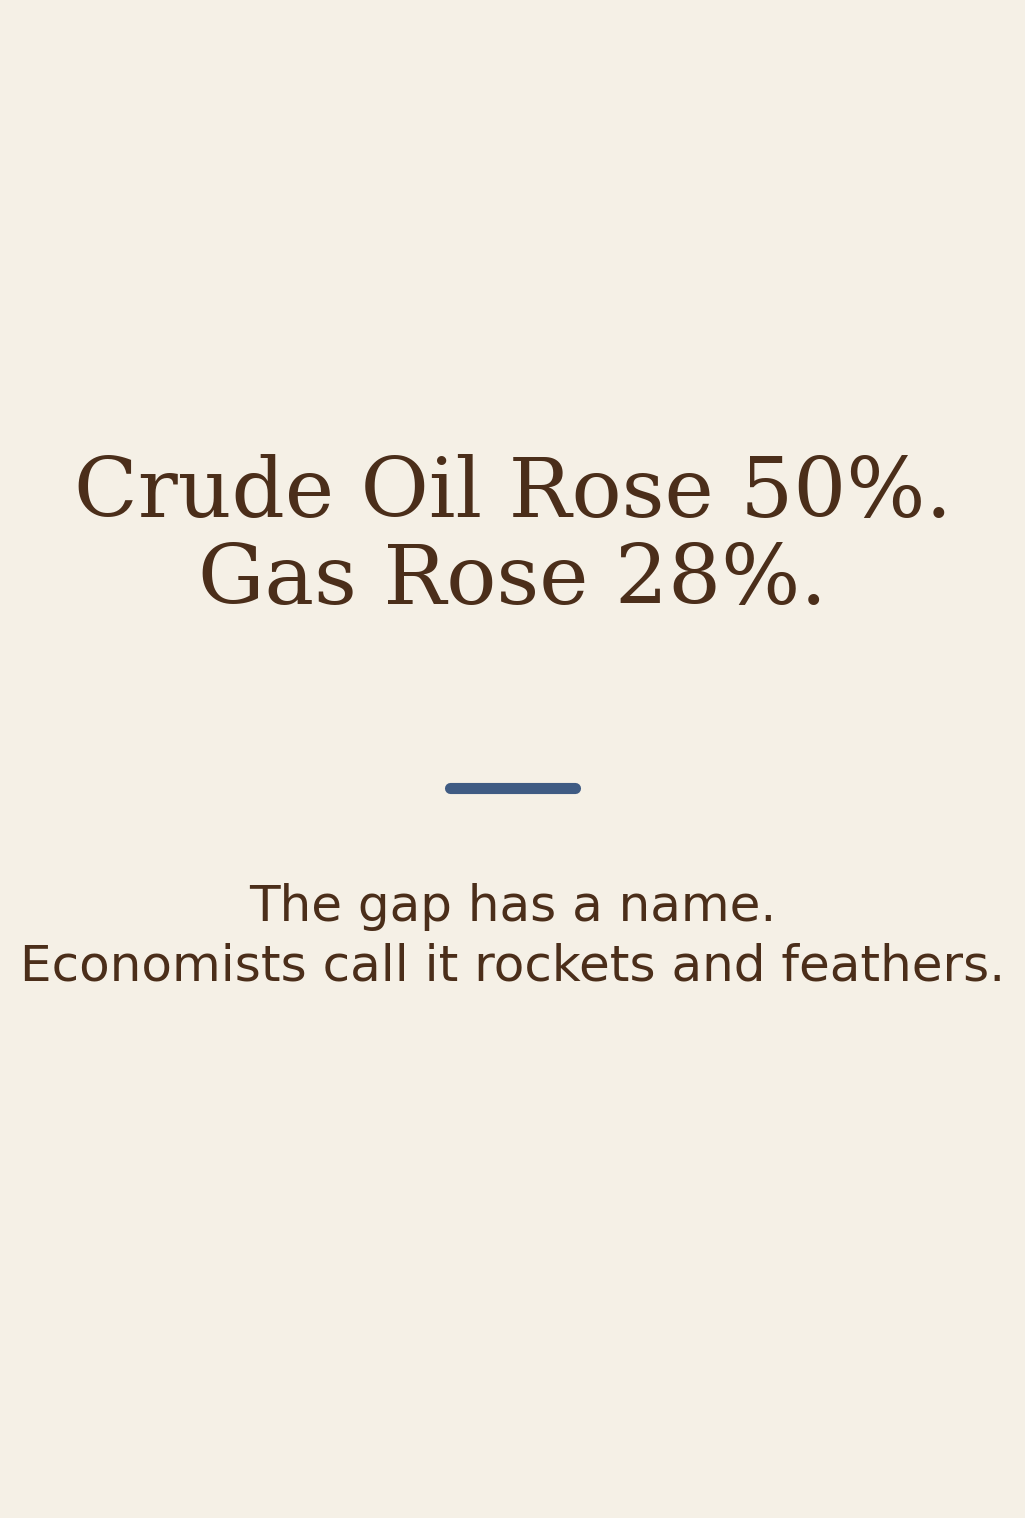

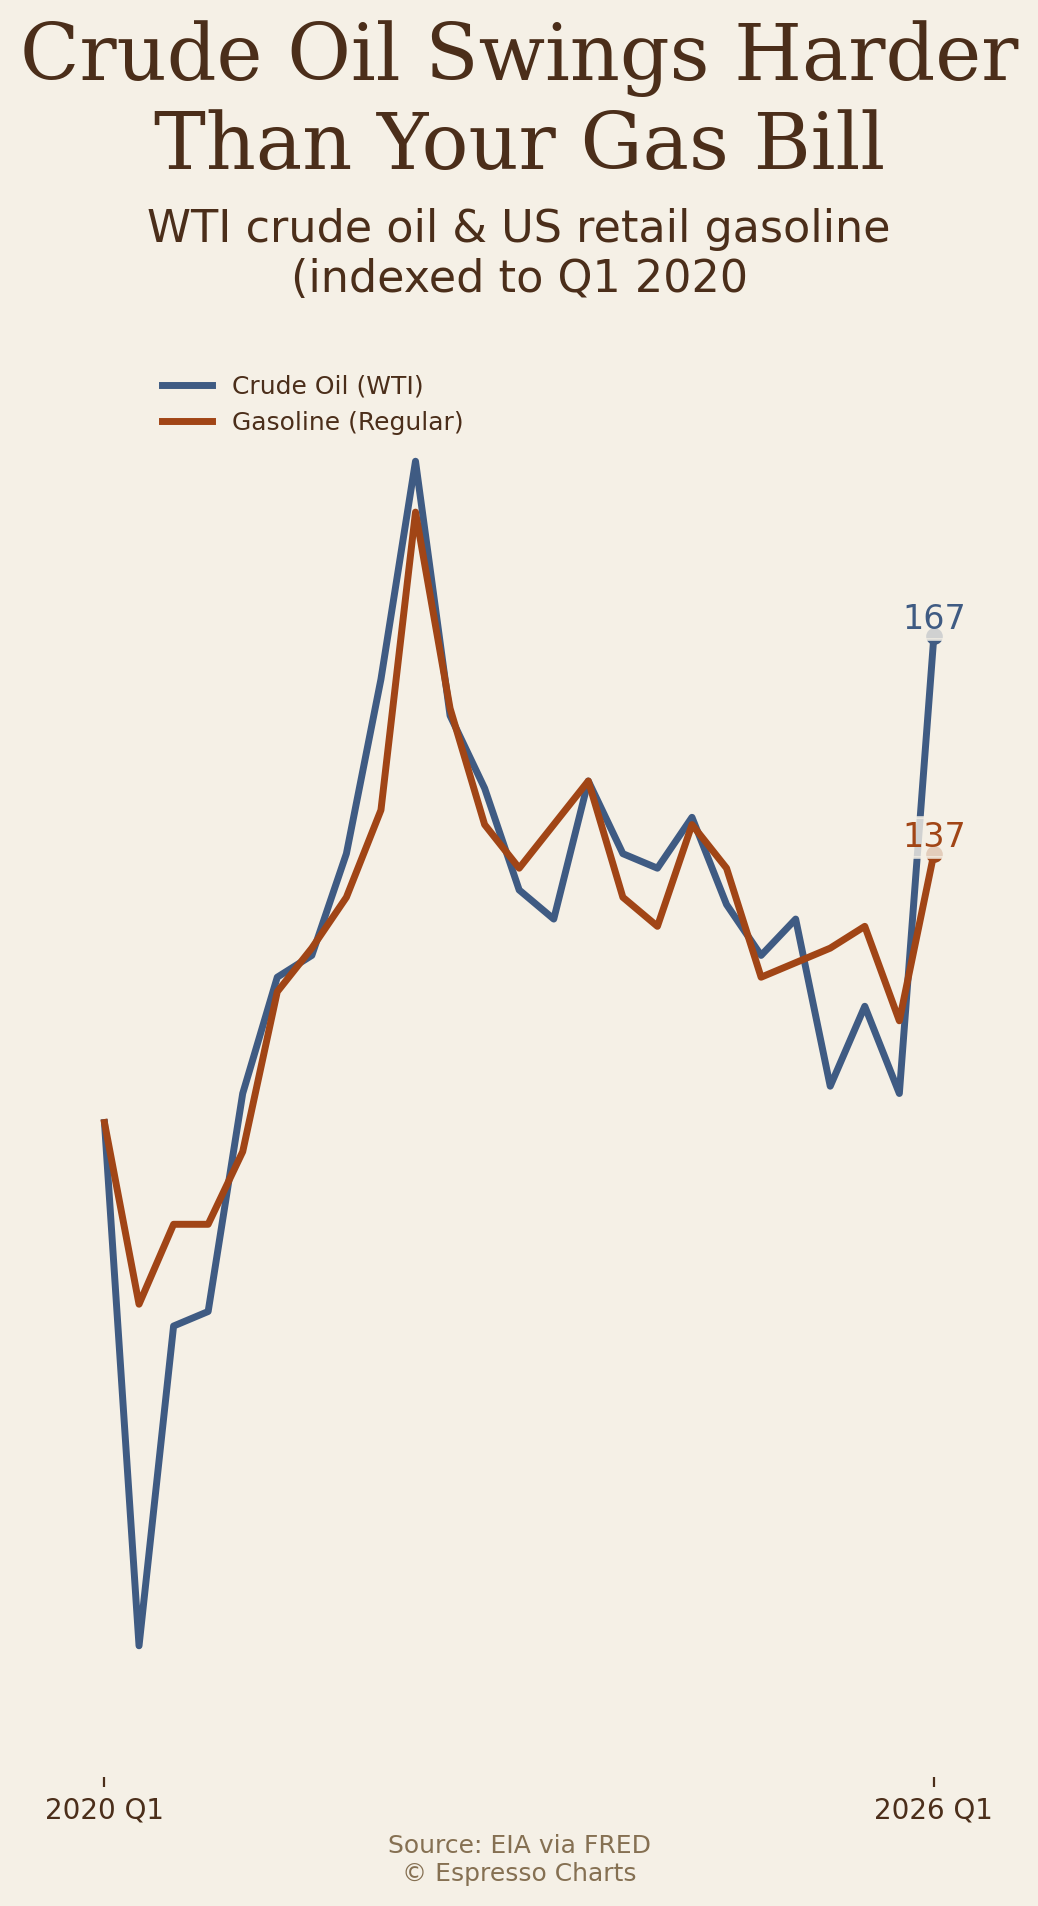

In [15]:
# INDIVIDUAL CREATION OF ASSETS

# Just story 2, everything
#run_config(config, story_ids=2)

# Story 1, only the second chart
#run_config(config, story_ids=0, only='stem_animate', chart_indices=1)
#run_config(config, story_ids=2, only='reel')

# Generate carousels
#run_config(config, story_ids=0, only='charts') #, chart_indices=1)
#run_config(config, story_ids=1, only='charts') #, chart_indices=1)
#run_config(config, story_ids=2, only='charts') #, chart_indices=2)

# Regenerate just the cover for story 0
#run_config(config, story_ids=0, only='cover')

# Only reels for stories 1 and 3
#run_config(config, story_ids=0)
run_config(config, story_ids=[0], only='reel')

# All PNGs, no video
#run_config(config, only=['cover', 'charts'])
#run_config(config, story_ids=0, only=['line_animate']) #line_animate, stem_animate


# Run all

In [ ]:
#run_config(config)